### 第4章 Seaborn 绘图
- Seaborn 是基于 Matplotlib 的 Python 可视化库。它提供了更高级的接口，用于绘制更具吸引力的统计图形
- 可以通过 `seaborn.load_dataset(name, cache=True, data_home=None, **kws)` 获取自带的数据集
    - `name`：数据集的名称，字符串
    - `cache`：设置是从本地加载还是从网络下载数据集，默认是`True`，表示从本地加载；若为`False`，则从网络下载数据集，并缓存在本地
    - `data_home`：数据集的缓存路径，默认是`None`，可以使用`get_data_home()`获取该缓存路径
    - `**kws`：键值对，传递给 pandas 模块 `read_csv()` 函数的附加参数

In [25]:
# 获取数据集默认存储路径
import seaborn as sns
print(sns.get_data_home())

C:\Users\Legion\AppData\Local\seaborn\seaborn\Cache


#### 6.1 Seaborn 绘图的基本设置
- 背景风格设置：`sns.set_style()` 和 `sns.axes_style()`。Seaborn有5个主题：
    - `darkgrid`: 灰色网格（默认值）
    - `whitegrid`: 白色网格
    - `dark`: 灰色背景
    - `white`: 白色背景
    - `ticks`: 四周带刻度线的白色背景
- 边框控制：
    - `sns.despine()`: 移除顶部和右侧边框
    - `sns.despine(offset=10, trim=True)`: 使两坐标轴分开一段距离
    - `sns.despine(left=True)`: 只移除左侧边框，常与 `sns.set_sytle("whitegrid")` 结合使用
    - `sns.despine(fig=None, ax=None, top=True, right=True, left=True, bottom=True, offset=None, trim=False)`: 移除指定边框   

#### 6.2 常用图表的绘制
##### 1. 绘制折线图
- 用 Seaborn 绘制折线图有两种方法：一种是在 `replot()` 函数中设置 `kind=line`，另一种是使用 `lineplot()` 函数直接绘制

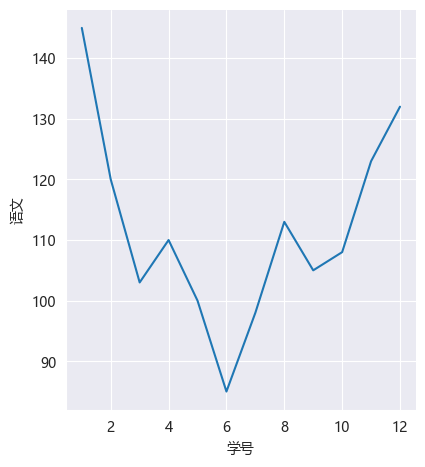

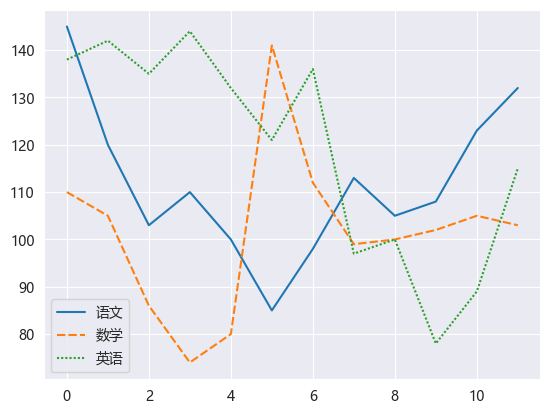

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]  # 解决中文乱码
df = pd.read_excel("../datas/data5.xlsx")  # 读取Excel文件
# fig, axes  = plt.subplots(nrows=1, ncols=2, figsize=(10,5))  # 创建子图

sns.relplot(x="学号", y="语文", kind="line", data=df)  # 绘制折线图
plt.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.1)  # 调整子图布局
plt.show()

dfs = [df["语文"], df["数学"], df["英语"]]
sns.lineplot(data=dfs)  # 绘制折线图
plt.show()

##### 2. 绘制直方图

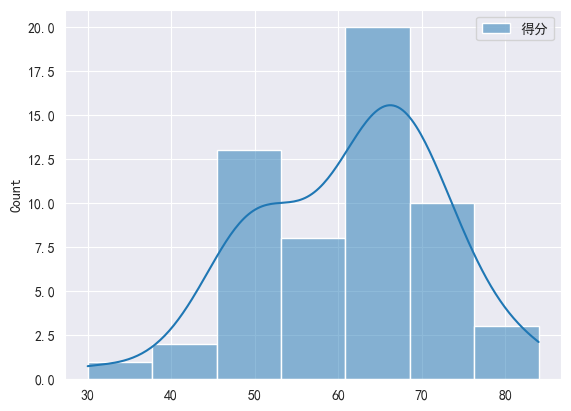

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码
df1 = pd.read_excel(io="../datas/data5.xlsx", sheet_name="英语")  # 读取Excel文件
data = df1[["得分"]]  # 数据
sns.histplot(data, kde=True)  # 直方图并拟合
plt.show()  # 显示图表

##### 3. 绘制直线图

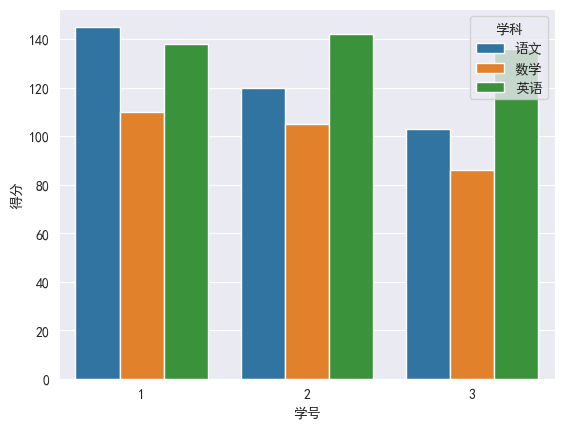

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码
df1 = pd.read_excel("../datas/data5.xlsx", sheet_name="sheet2")  # 读取Excel文件
sns.barplot(x="学号", y="得分", hue="学科", data=df1)  # 条形图
plt.show()  # 显示图表

##### 4. 绘制散点图

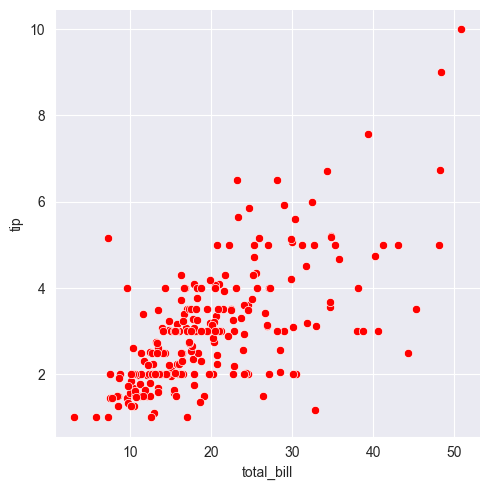

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
# 加载内置数据集 tips(小费数据集)，并对 total_bill 和 tip 字段绘制散点图
custom_path = "../seaborn-data-master"
tips = sns.load_dataset("tips", data_home=custom_path)
sns.relplot(x="total_bill", y="tip", data=tips, color="r")  # 绘制散点图
plt.show()  # 显示图表

##### 5. 绘制线性回归模型
- `sns.lmplot(x, y, data, hue=None, col=None, row=None, palette=None, col_wrap=3, size=5, markers='o')`
    - `hue`：设置散点图中的分类字段，用于绘制不同颜色的线
    - `col`：列分类变量，构成子集
    - `row`：行分类变量
    - `col_wrap`：控制每行子图的数量
    - `size`：控制每个子图的大小
    - `markers`：控制散点图的标记

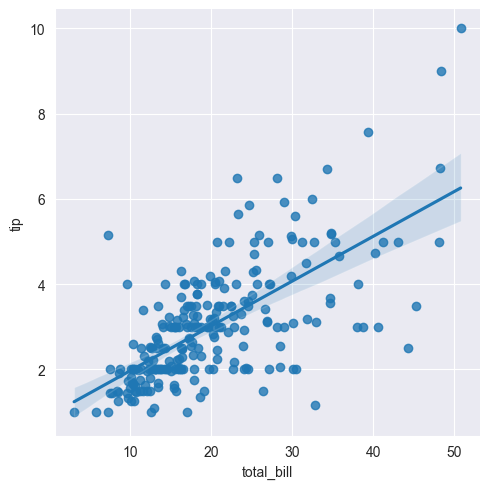

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
# 加载内置数据集 tips(小费数据集)，并对 total_bill 和 tip 字段绘制线性回归
custom_path = "../seaborn-data-master"
tips = sns.load_dataset("tips", data_home=custom_path)
sns.lmplot(x="total_bill", y="tip", data=tips)
plt.show()  # 显示图表

##### 6. 绘制箱线图
- `sns.boxplot(x, y, data, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, width=0.8, notch=False)`
    - `hue`：设置分类字段
    - `width`：设置箱线图宽度
    - `notch`：设置中间箱体是否显示缺口，默认为False，不显示

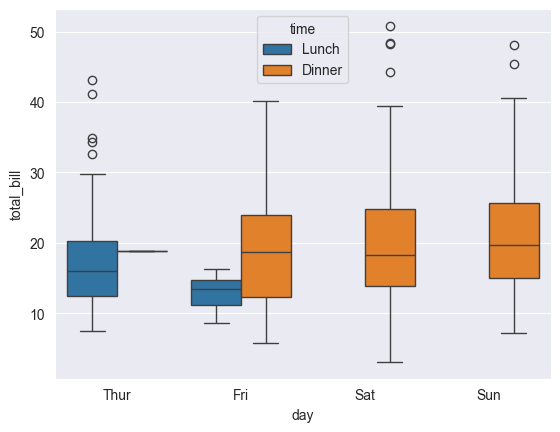

In [ ]:
# 导入相关模块
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
# 加载内置数据集tips（小费数据集），并对total_bill和tip字段绘制箱线图
custom_path = "../seaborn-data-master"
tips = sns.load_dataset("tips", data_home=custom_path)
sns.boxplot(x="day", y="total_bill", hue="time", data=tips)
plt.show()  # 显示图表

##### 7. 绘制核密度图
- 核密度估计是概率论中用来估计未知的密度函数的一种方法，属于非参数检验方法之一。通过核密度图可以直观地看出数据样本的分布特征
- `sns..kdeplot(data, shade=True)`
    - `data`：数据集
    - `shade`：是否带阴影，默认为True，即有阴影

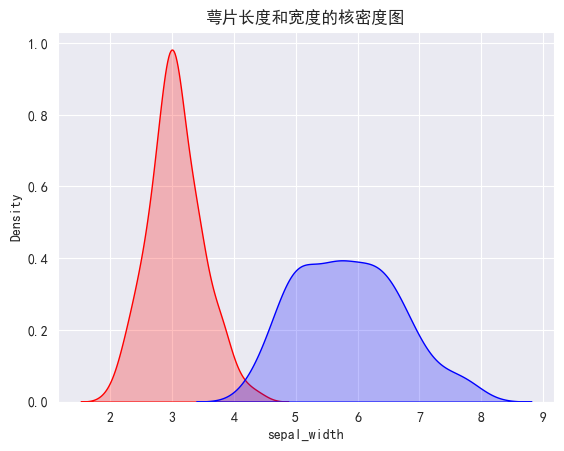

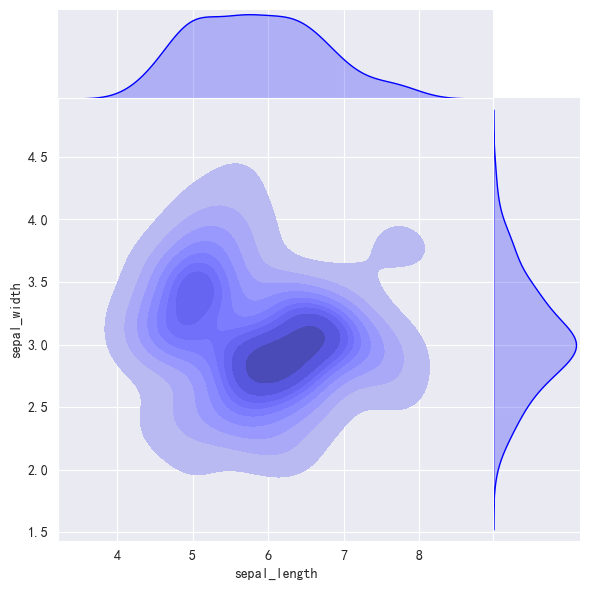

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文显示问题
# 调用seaborn自带数据集iris
custom_path = "../seaborn-data-master"
df = sns.load_dataset("iris", data_home=custom_path)
# 绘制多个变量的核密度图
sns.kdeplot(df['sepal_width'], fill=True, color="r")
sns.kdeplot(df['sepal_length'], fill=True, color="b")
plt.title("萼片长度和宽度的核密度图")
plt.show()  # 显示图表

# 绘制边际核密度图
sns.jointplot(
    x=df["sepal_length"], y=df["sepal_width"], kind="kde", space=0, fill=True, color="b"
)
plt.show()  # 显示图表


##### 8. 绘制提琴图
- 提琴图结合了箱线图和核密度图的特征，用于展示数据的分布情况。粗黑线表示四分位数范围，延伸的细线表示95%的置信区间，白点为中位数

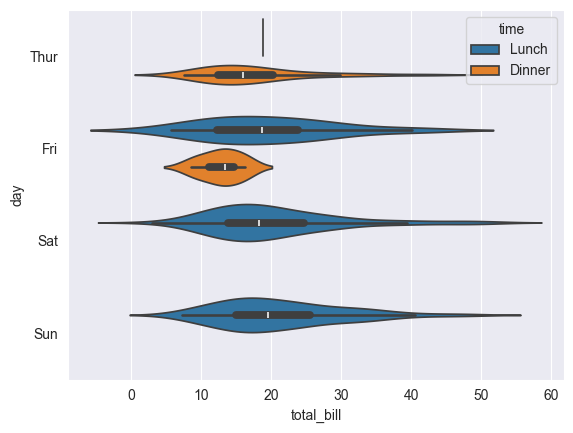

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # 灰色网格
# 调用seaborn自带数据集tips
custom_path = "../seaborn-data-master"
tips = sns.load_dataset("tips", data_home=custom_path)
# 绘制提琴图
sns.violinplot(x="total_bill", y="day", hue="time", data=tips)
plt.show()  # 显示图表

#### 6.3 

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


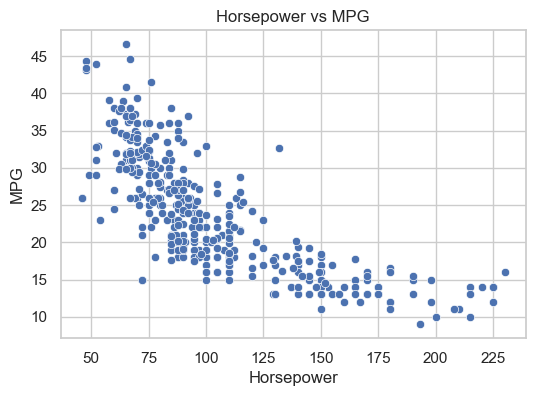

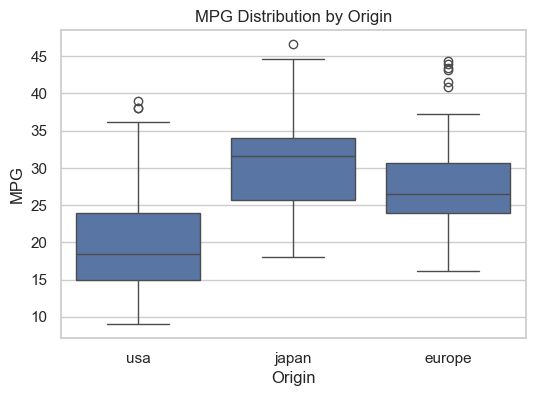

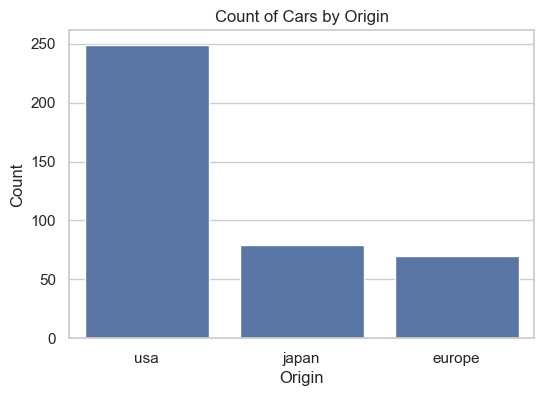

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.778427 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.842983  0.896017   
displacement -0.804203   0.950721      1.000000    0.897257  0.932824   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.831741   0.896017      0.932824    0.864538  1.000000   
acceleration  0.420289  -0.505419     -0.543684   -0.689196 -0.417457   
model_year    0.579267  -0.348746     -0.370164   -0.416361 -0.306564   

              acceleration  model_year  
mpg               0.420289    0.579267  
cylinders        -0.505419   -0.348746  
displacement     -0.543684   -0.370164  
horsepower       -0.689196   -0.416361  
weight           -0.417457   -0.306564  
acceleration      1.000000    0.288137  
model_year        0.288137    1.000000  


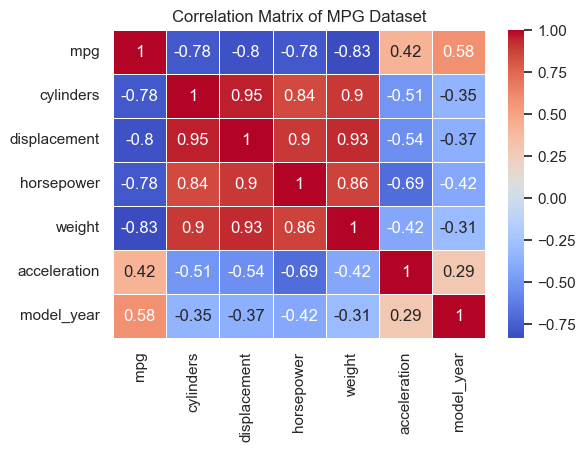

In [51]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 这里我们使用 Seaborn 自带的 mpg 数据集
custom_path = "../seaborn-data-master"
mpg = sns.load_dataset("mpg", data_home=custom_path)
# 查看数据集的前几行以了解其内容
print(mpg.head())

# 设置 Seaborn 的样式（可选）
sns.set(style="whitegrid")
# 绘制散点图：horsepower 与 mpg（每加仑英里数）之间的关系
plt.figure(figsize=(6, 4))
sns.scatterplot(x="horsepower", y="mpg", data=mpg)
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

# 绘制箱线图：按 origin（原产地）分组查看 mpg 的分布情况
plt.figure(figsize=(6, 4))
sns.boxplot(x="origin", y="mpg", data=mpg)
plt.title("MPG Distribution by Origin")
plt.xlabel("Origin")
plt.ylabel("MPG")
plt.show()

# 绘制计数图：查看不同 origin 的车辆数量
plt.figure(figsize=(6, 4))
sns.countplot(x="origin", data=mpg)
plt.title("Count of Cars by Origin")
plt.xlabel("Origin")
plt.ylabel("Count")
plt.show()

# 绘制热力图：查看不同变量之间的相关性（需要先计算相关性矩阵）
correlation_matrix = mpg.iloc[:, :7].corr()  # 这里使用 pandas 的 corr() 方法计算相关性
print(correlation_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of MPG Dataset")
plt.show()